In [110]:
pip install matplotlib seaborn pyyaml

Note: you may need to restart the kernel to use updated packages.


In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
import warnings
warnings.simplefilter("ignore")  # in=gnore warning messages

In [113]:
df = pd.read_csv("train.csv")
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN25630,2,1,2,1,Meal Plan 1,0,Room_Type 1,26,2017,10,17,Online,0,0,0,161.00,0,Not_Canceled
1,INN14474,2,1,1,1,Meal Plan 1,0,Room_Type 1,98,2018,7,16,Online,0,0,0,121.50,2,Not_Canceled
2,INN23721,2,0,0,3,Meal Plan 1,0,Room_Type 1,433,2018,9,8,Offline,0,0,0,70.00,0,Canceled
3,INN05844,2,0,2,5,Meal Plan 1,0,Room_Type 1,195,2018,8,8,Offline,0,0,0,72.25,0,Not_Canceled
4,INN18710,1,0,0,2,Meal Plan 1,0,Room_Type 1,188,2018,6,15,Offline,0,0,0,130.00,0,Canceled


In [114]:
df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='str')

In [115]:
df = df.drop(columns=["Booking_ID"])

In [116]:
df.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [117]:
df.duplicated().sum()

np.int64(7661)

In [118]:
df = df.drop_duplicates()

In [119]:
df["no_of_adults"].value_counts()

no_of_adults
2    15489
1     3996
3     1748
0      113
4       13
Name: count, dtype: int64

In [120]:
df["no_of_children"].value_counts()

no_of_children
0     19251
1      1257
2       837
3        11
9         2
10        1
Name: count, dtype: int64

In [121]:
df["no_of_weekend_nights"].value_counts()

no_of_weekend_nights
0    9178
1    6063
2    5882
3     110
4      91
5      21
6      14
Name: count, dtype: int64

In [122]:
df["no_of_week_nights"].value_counts()

no_of_week_nights
2     5894
1     5833
3     4628
4     1980
0     1492
5     1169
6      136
7       81
8       43
10      41
9       24
11      12
15       7
12       6
14       5
13       4
16       2
17       2
Name: count, dtype: int64

In [123]:
df["type_of_meal_plan"].value_counts()

type_of_meal_plan
Meal Plan 1     16759
Not Selected     3627
Meal Plan 2       969
Meal Plan 3         4
Name: count, dtype: int64

In [124]:
df["required_car_parking_space"].value_counts()

required_car_parking_space
0    20452
1      907
Name: count, dtype: int64

In [125]:
df["room_type_reserved"].value_counts()

room_type_reserved
Room_Type 1    15375
Room_Type 4     4403
Room_Type 6      758
Room_Type 2      500
Room_Type 5      190
Room_Type 7      129
Room_Type 3        4
Name: count, dtype: int64

In [126]:
df["arrival_year"].value_counts()

arrival_year
2018    18141
2017     3218
Name: count, dtype: int64

In [127]:
df["arrival_month"].value_counts()

arrival_month
10    2663
9     2525
8     2477
12    1928
7     1893
11    1817
4     1695
3     1611
6     1543
5     1522
2     1067
1      618
Name: count, dtype: int64

In [128]:
df["market_segment_type"].value_counts()

market_segment_type
Online           16324
Offline           3471
Corporate         1192
Complementary      291
Aviation            81
Name: count, dtype: int64

In [129]:
df["repeated_guest"].value_counts()

repeated_guest
0    20667
1      692
Name: count, dtype: int64

In [130]:
df["no_of_previous_cancellations"].value_counts()

no_of_previous_cancellations
0     21135
1       115
2        36
3        32
11       20
5        10
4         9
13        1
6         1
Name: count, dtype: int64

In [131]:
df["booking_status"].value_counts()

booking_status
Not_Canceled    15231
Canceled         6128
Name: count, dtype: int64

Data is imbalanced w.r.t "booking_status" columns

In [132]:
df.info()

<class 'pandas.DataFrame'>
Index: 21359 entries, 0 to 29019
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21359 non-null  int64  
 1   no_of_children                        21359 non-null  int64  
 2   no_of_weekend_nights                  21359 non-null  int64  
 3   no_of_week_nights                     21359 non-null  int64  
 4   type_of_meal_plan                     21359 non-null  str    
 5   required_car_parking_space            21359 non-null  int64  
 6   room_type_reserved                    21359 non-null  str    
 7   lead_time                             21359 non-null  int64  
 8   arrival_year                          21359 non-null  int64  
 9   arrival_month                         21359 non-null  int64  
 10  arrival_date                          21359 non-null  int64  
 11  market_segment_type            

In [133]:
catogorical_columns = [cols for cols in df.columns if df[cols].dtype == "str"]

In [134]:
catogorical_columns.extend(["type_of_meal_plan","required_car_parking_space"])

In [135]:
catogorical_columns.append("repeated_guest")

In [136]:
numerical_columns = [col for col in df.columns if col not in catogorical_columns]

In [137]:
numerical_columns

['no_of_adults',
 'no_of_children',
 'no_of_weekend_nights',
 'no_of_week_nights',
 'lead_time',
 'arrival_year',
 'arrival_month',
 'arrival_date',
 'no_of_previous_cancellations',
 'no_of_previous_bookings_not_canceled',
 'avg_price_per_room',
 'no_of_special_requests']

##### Data Analysis


In [138]:
data = df.copy()

In [139]:
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,1,2,1,Meal Plan 1,0,Room_Type 1,26,2017,10,17,Online,0,0,0,161.00,0,Not_Canceled
1,2,1,1,1,Meal Plan 1,0,Room_Type 1,98,2018,7,16,Online,0,0,0,121.50,2,Not_Canceled
2,2,0,0,3,Meal Plan 1,0,Room_Type 1,433,2018,9,8,Offline,0,0,0,70.00,0,Canceled
3,2,0,2,5,Meal Plan 1,0,Room_Type 1,195,2018,8,8,Offline,0,0,0,72.25,0,Not_Canceled
4,1,0,0,2,Meal Plan 1,0,Room_Type 1,188,2018,6,15,Offline,0,0,0,130.00,0,Canceled


#### Univariate Analysis

##### For Numerical Columns

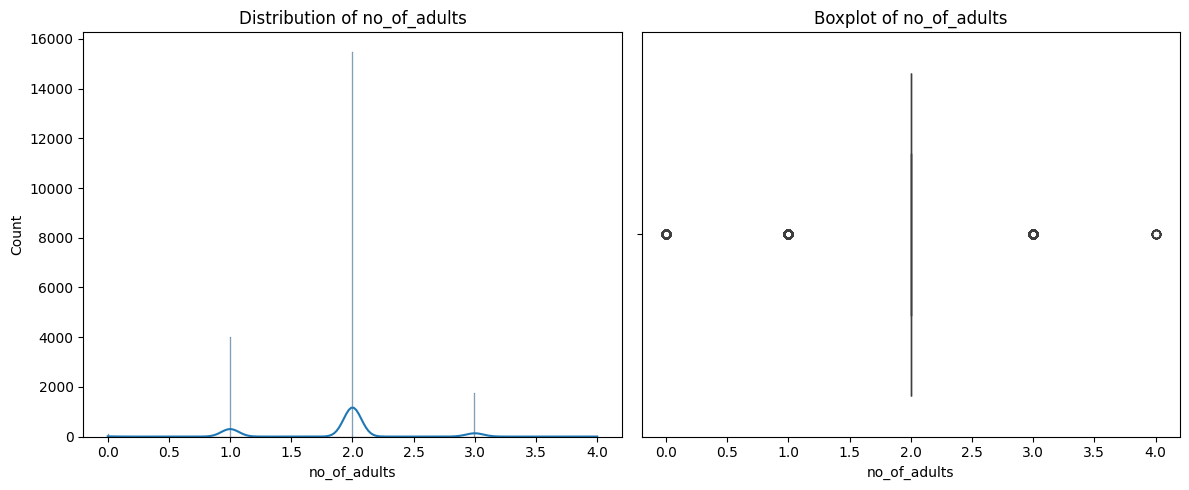

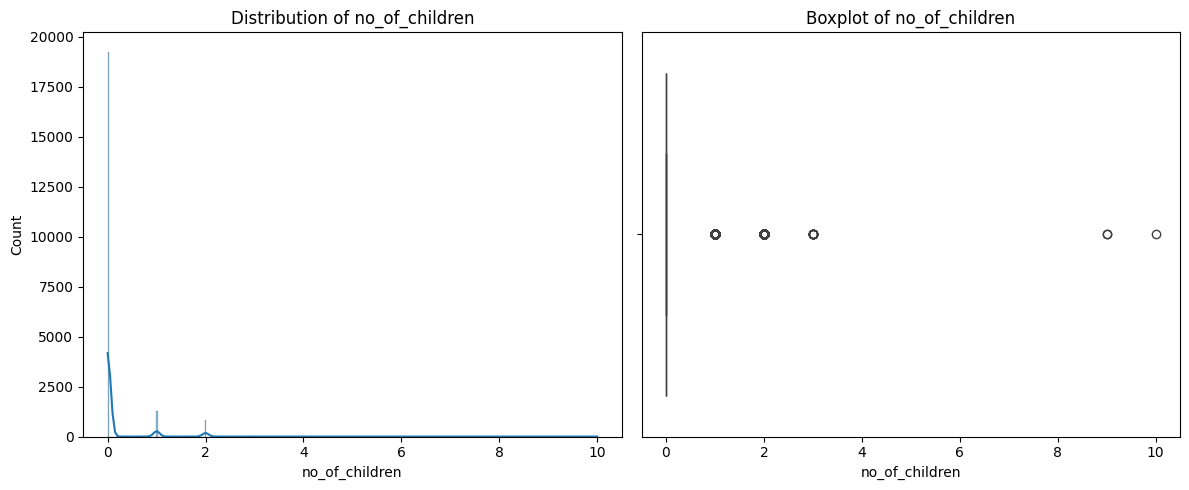

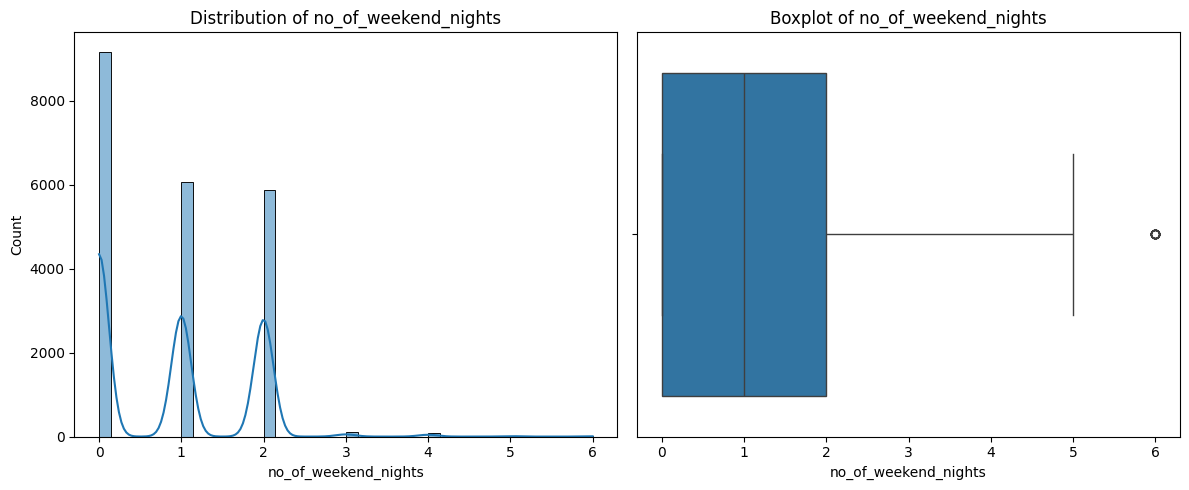

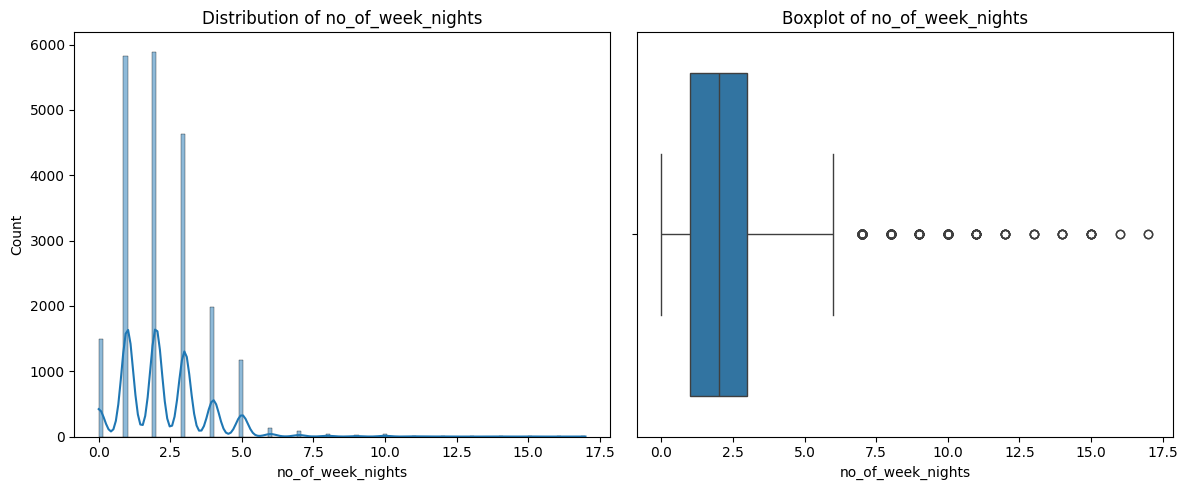

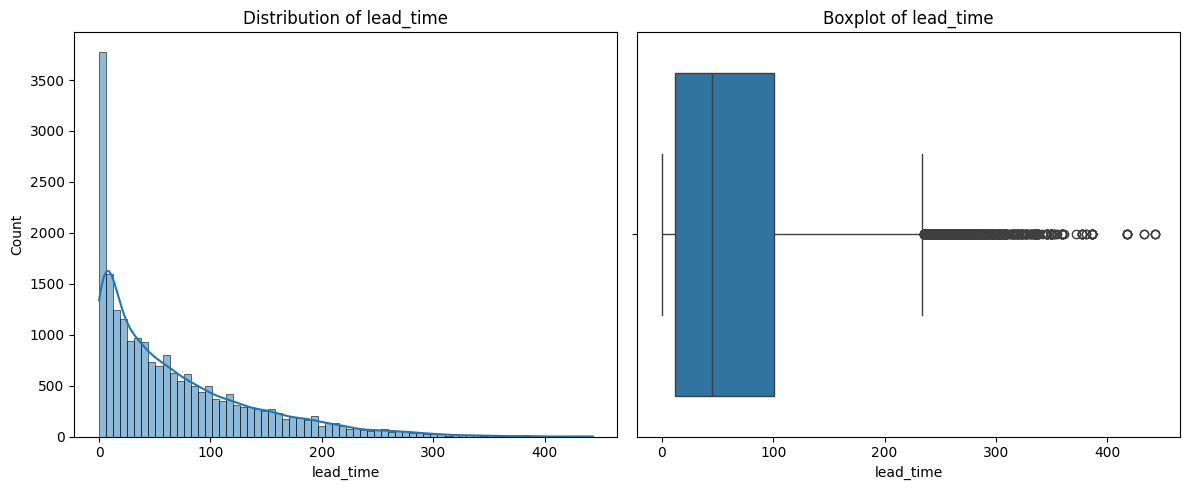

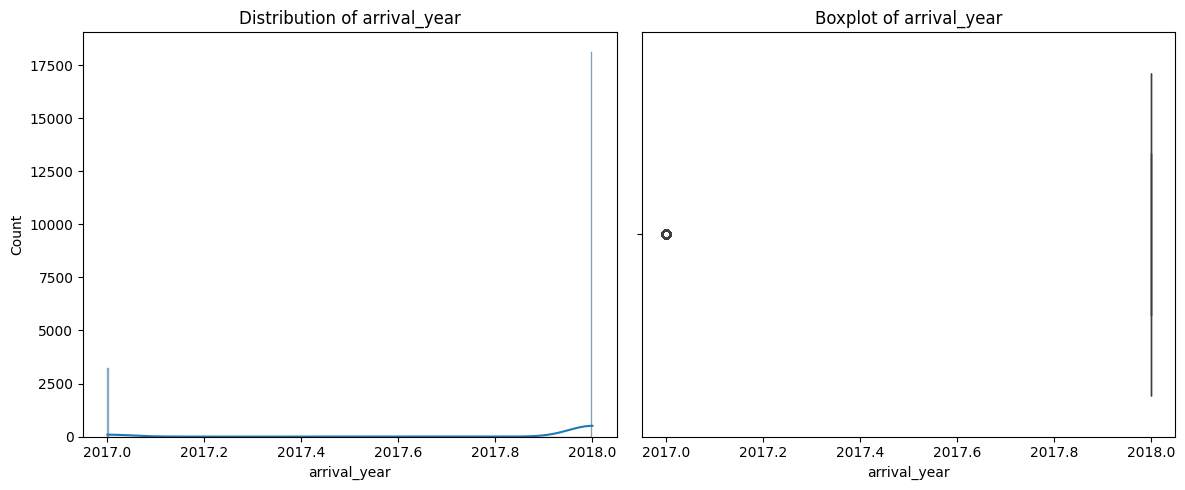

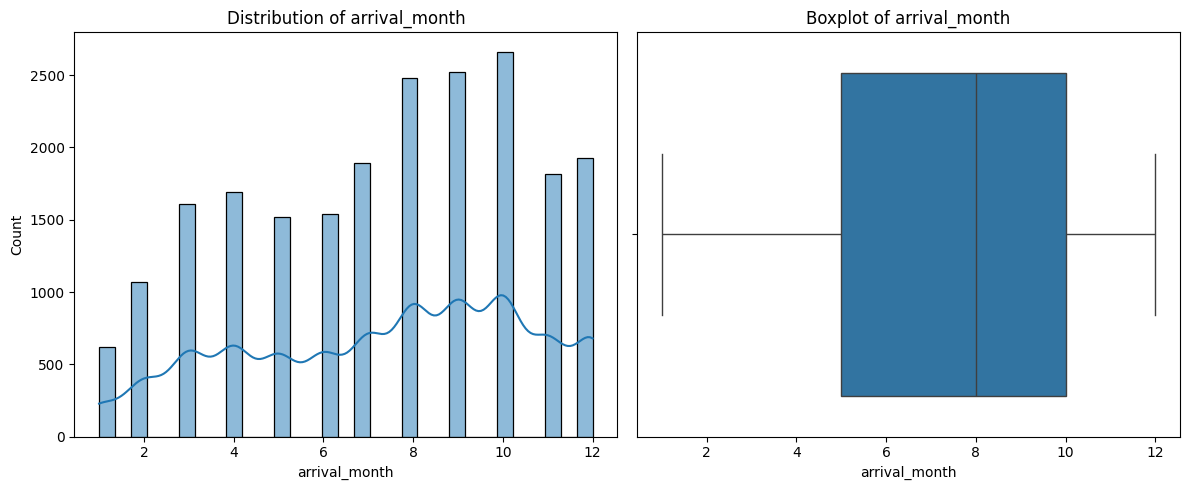

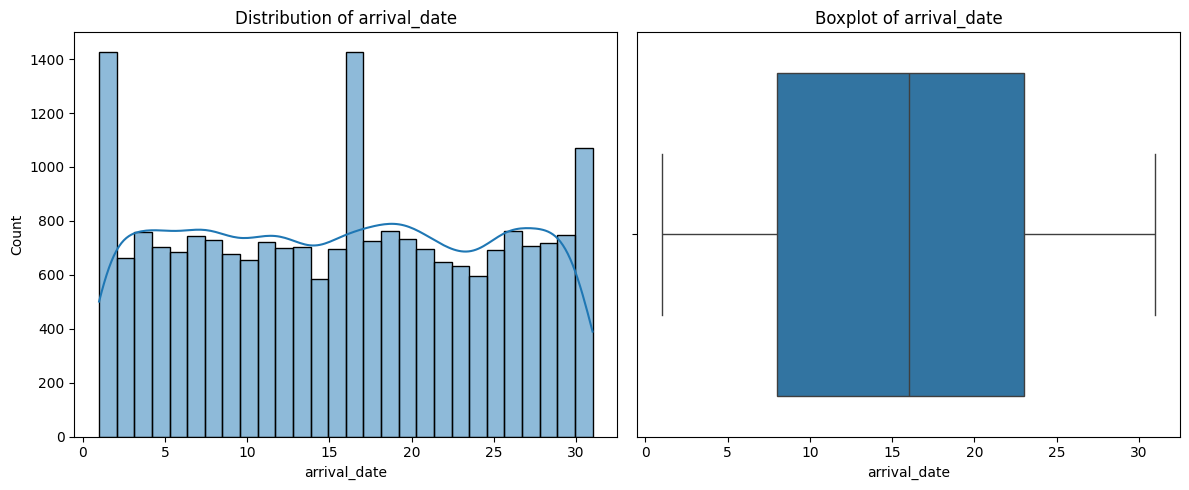

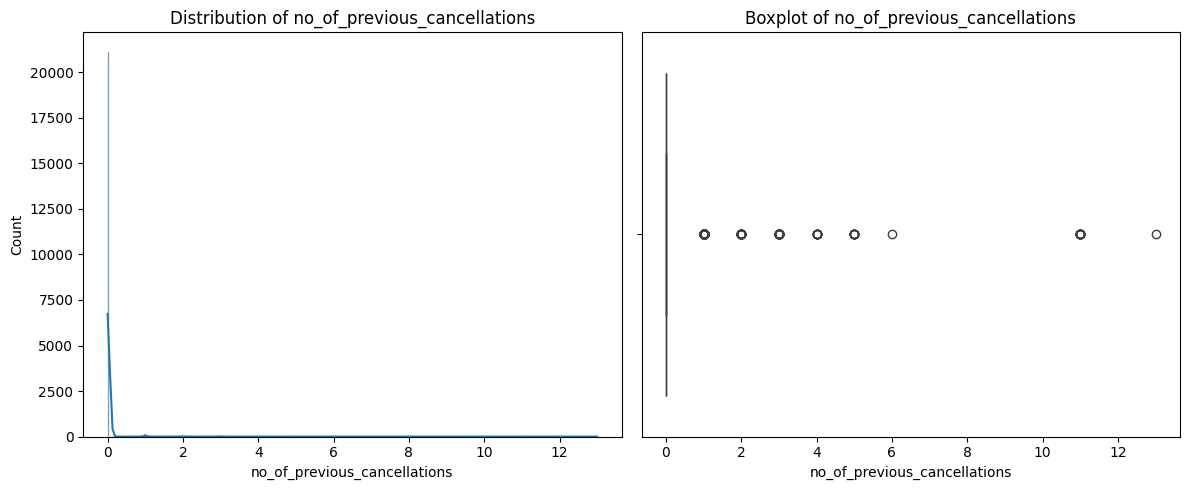

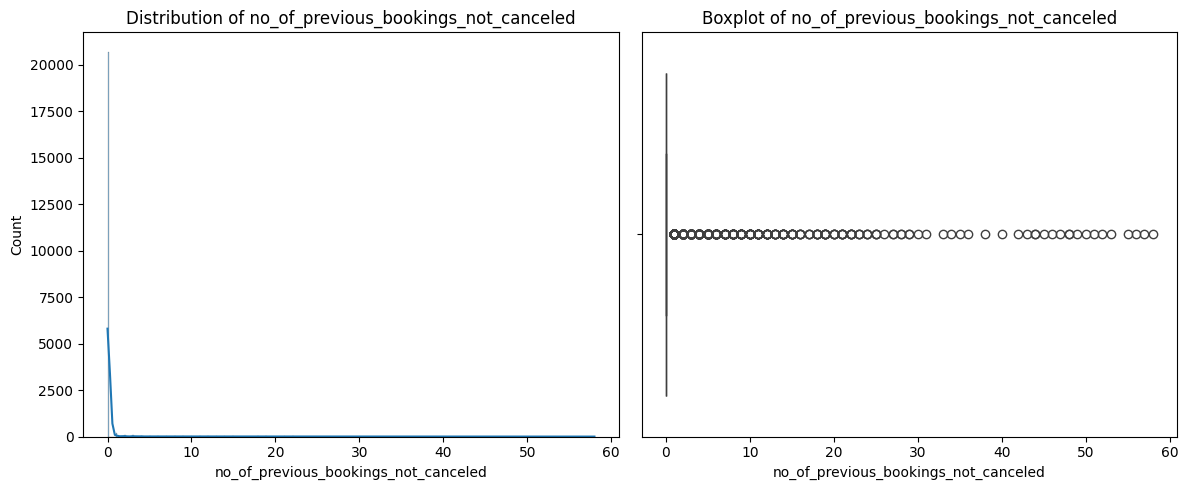

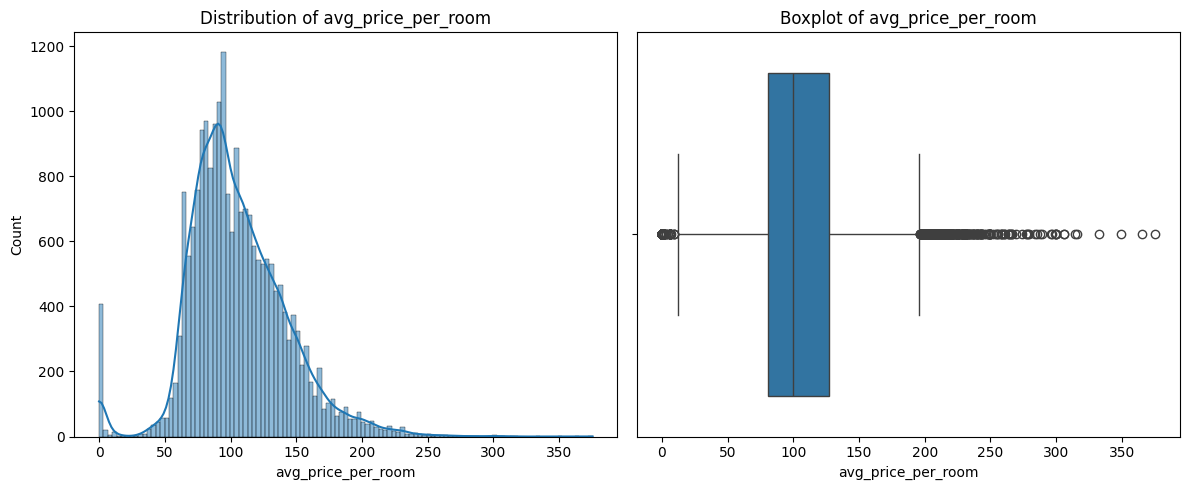

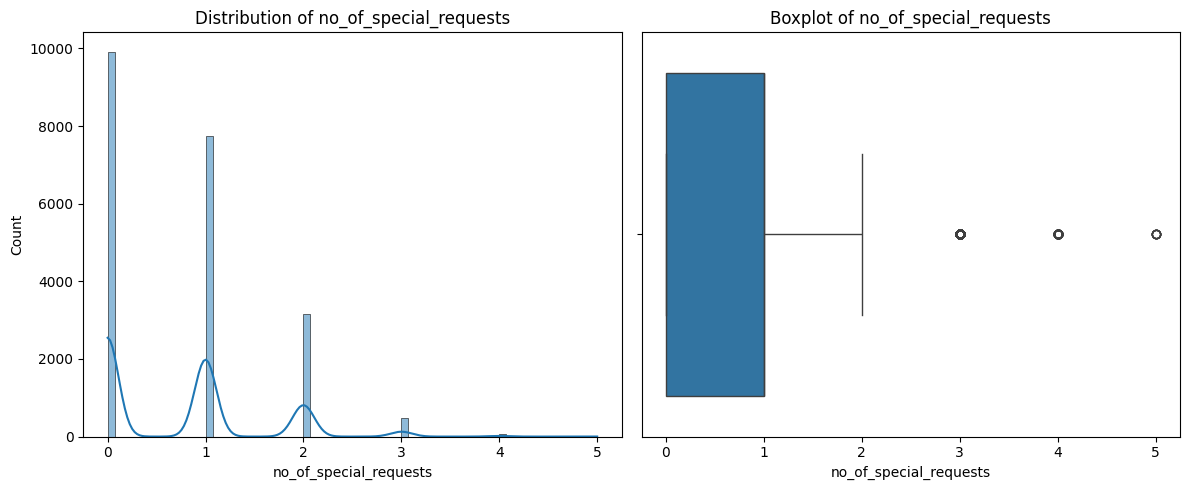

In [140]:
# Histogram and BoxPlot
for cols in numerical_columns:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(data[cols], kde=True, palette="Blues")
    plt.title(f"Distribution of {cols}")
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[cols])
    plt.title(f"Boxplot of {cols}")
    
    plt.tight_layout()
    plt.show()


##### For Categorical Columns

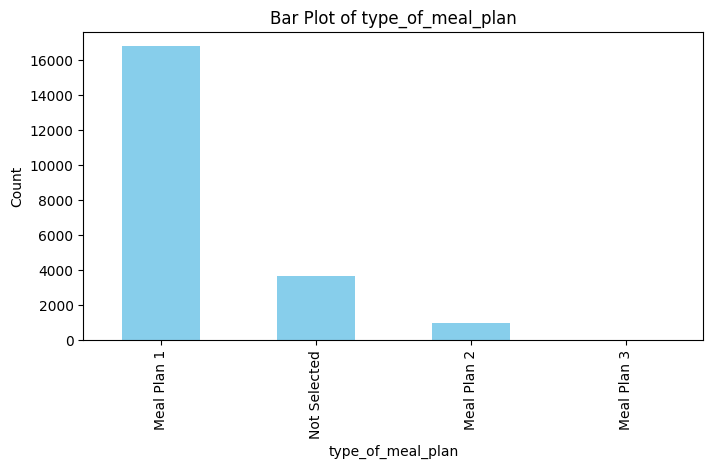

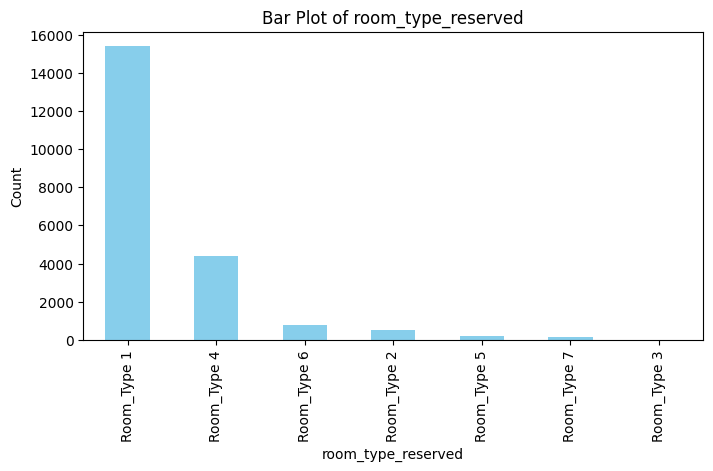

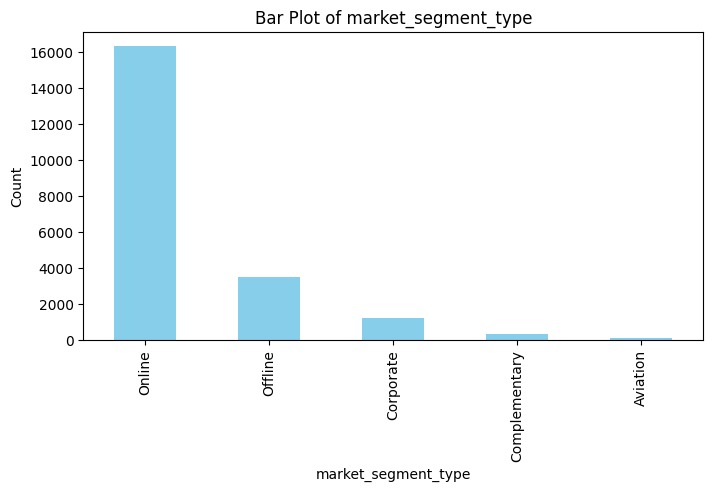

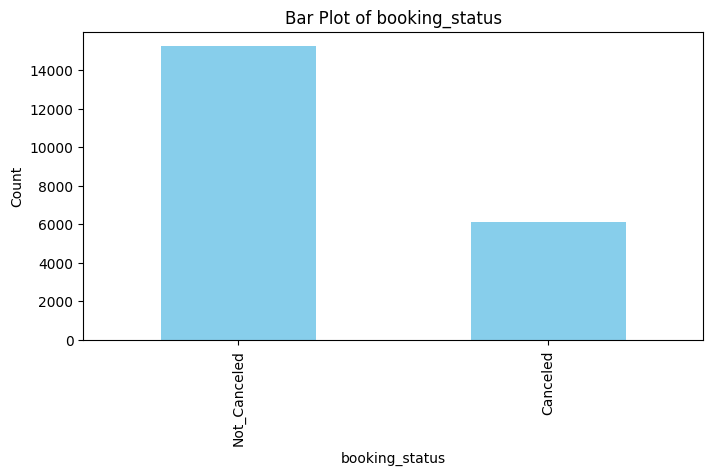

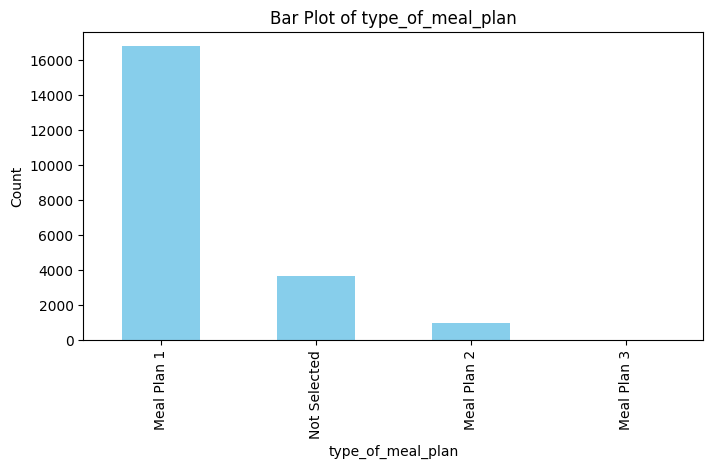

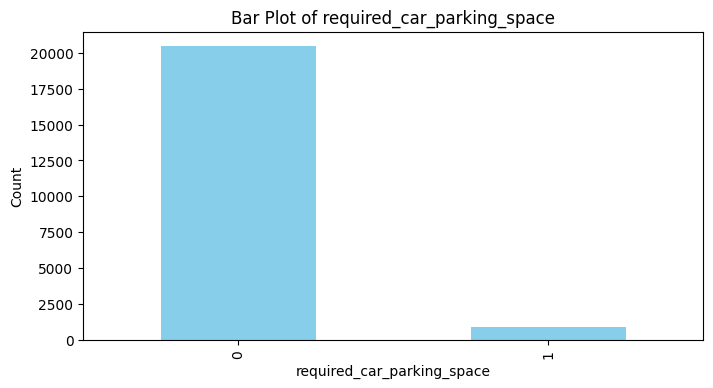

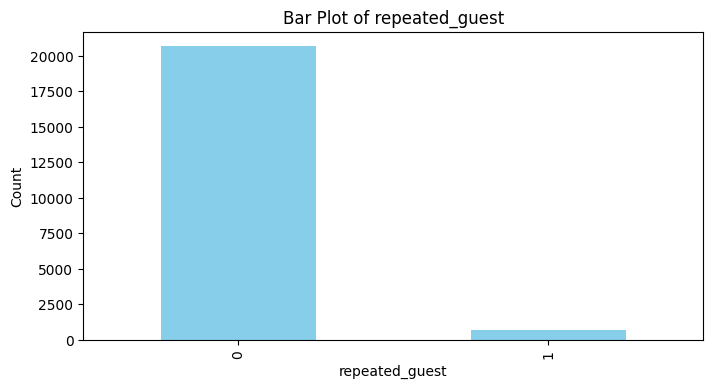

In [141]:
for cols in catogorical_columns:
    plt.figure(figsize=(8, 4))
    data[cols].value_counts().plot(kind="bar", color="skyblue")
    plt.title(f"Bar Plot of {cols}")
    plt.xlabel(cols)
    plt.ylabel("Count")
    plt.show()

##### Bivariate Analysis

In [142]:
# For Numerical Columns
def plot_bivariate_num(df , target , num_features):
    num_plots = len(num_features)
    num_rows = (len(num_features)+1)//2

    fig , axes = plt.subplots(num_rows , 2 , figsize=(15 , num_rows*5))
    axes = axes.flatten()

    for i , column in enumerate(num_features):
        sns.boxplot(x=target, y=column, ax=axes[i], data=data, palette="Blues")
        axes[i].set_title(f"{column} VS {target}")

    plt.tight_layout()
    plt. show()


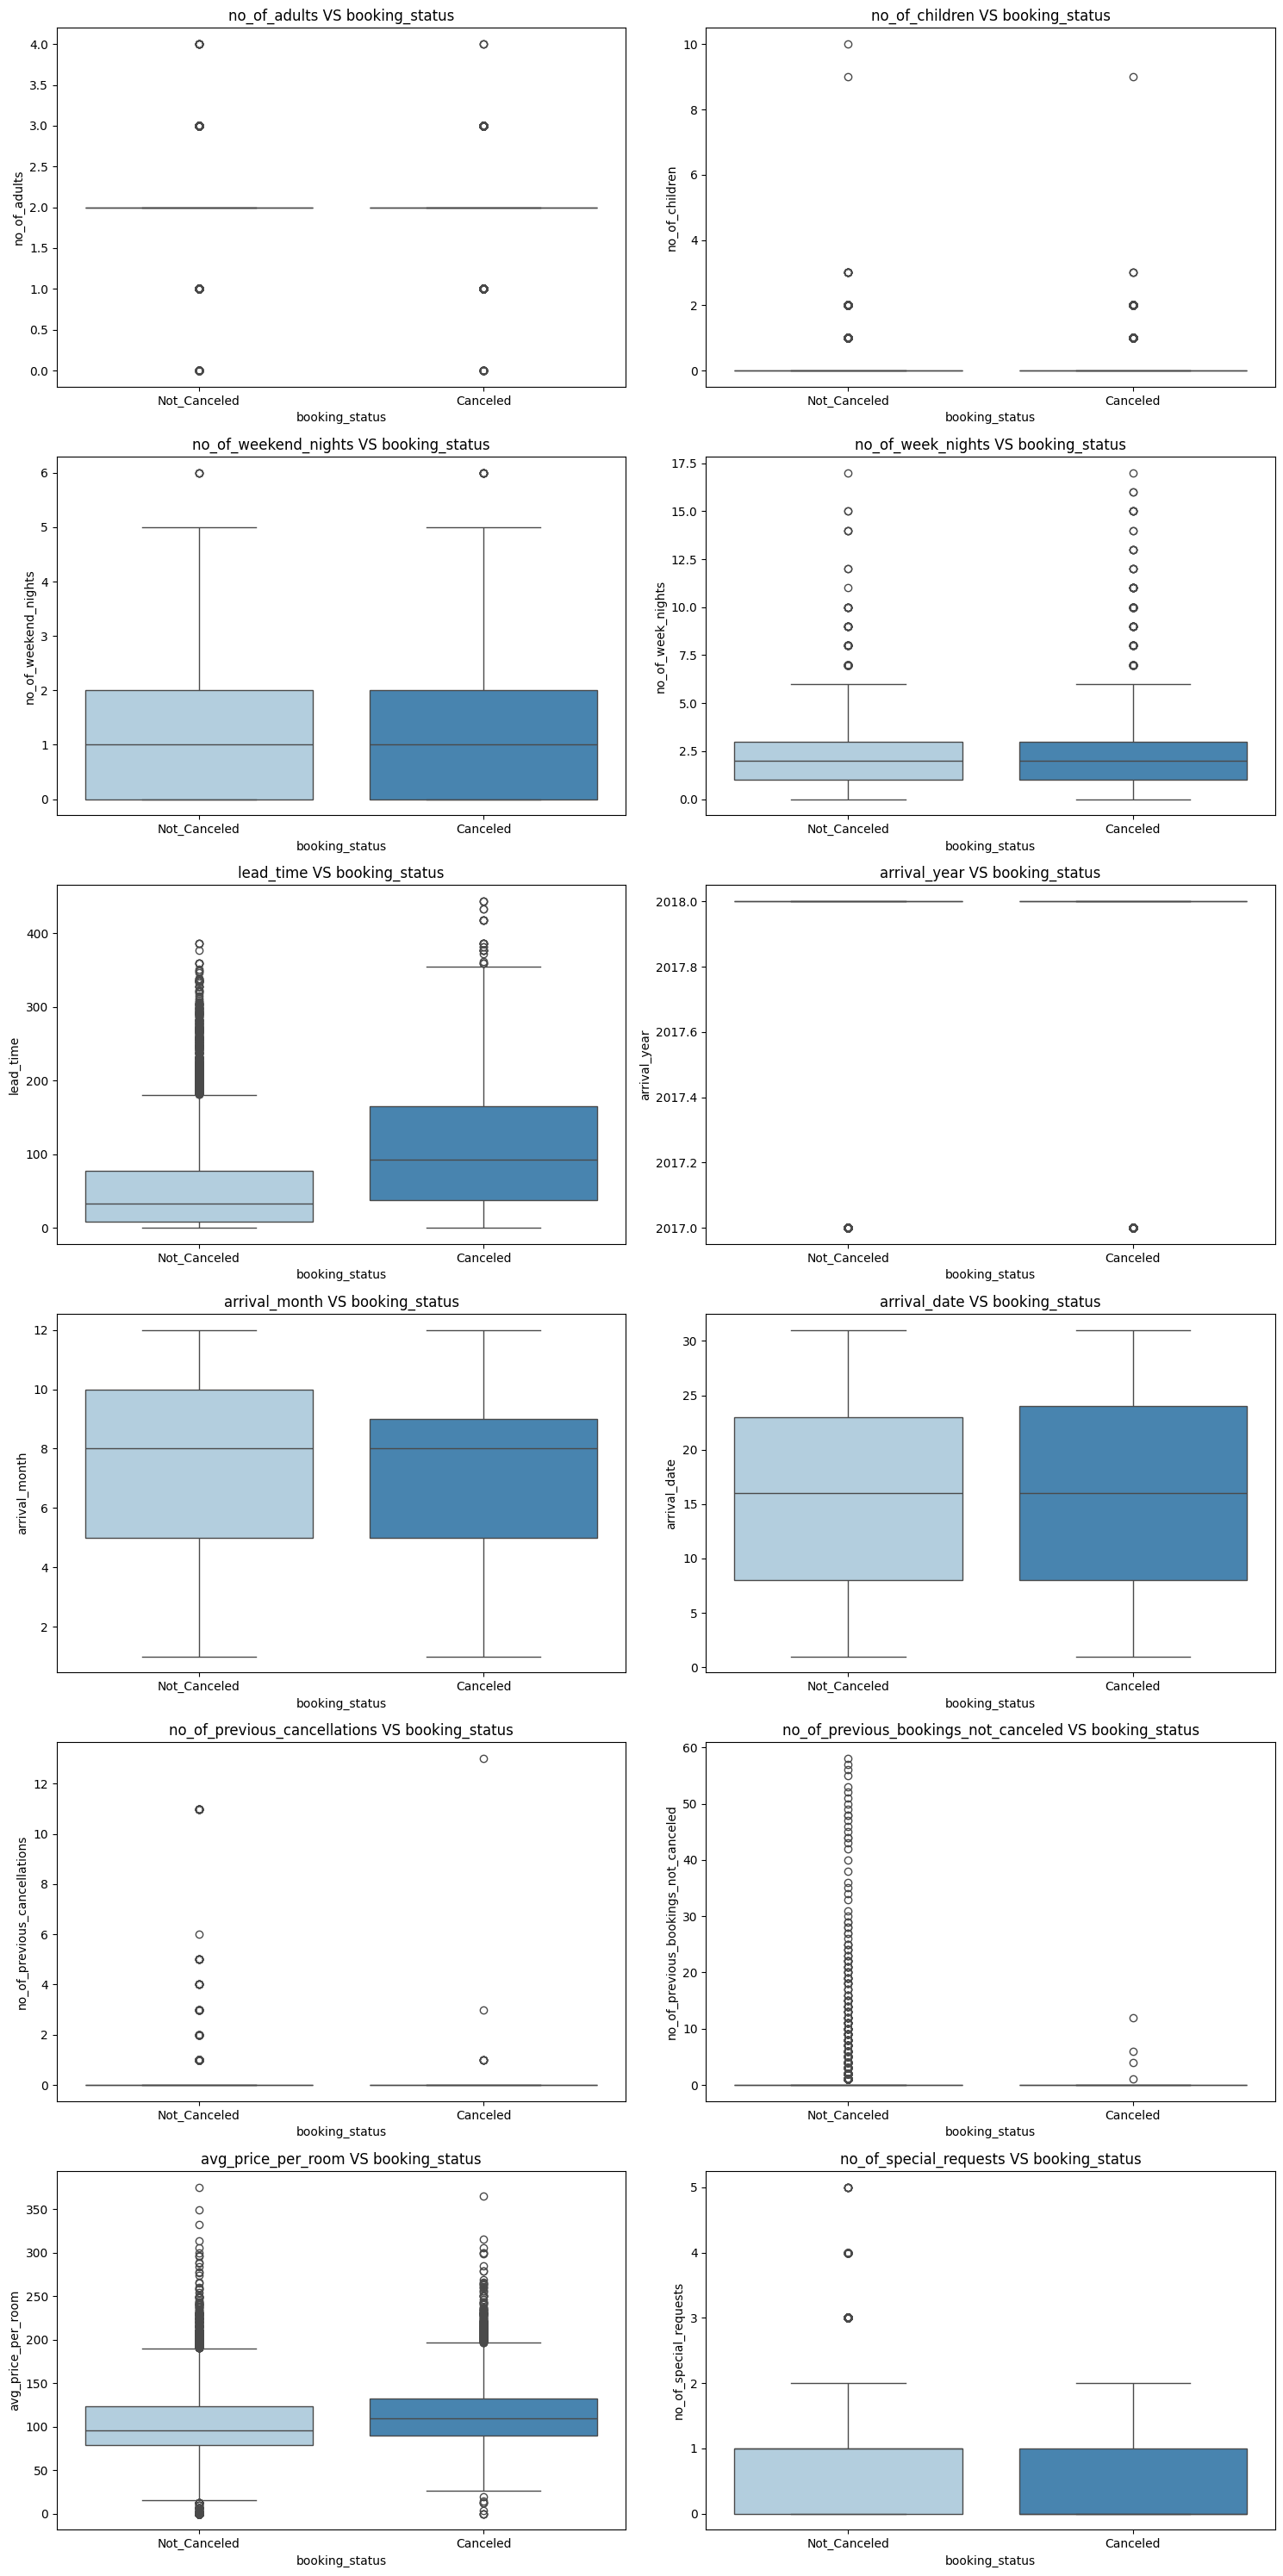

In [143]:
plot_bivariate_num(data , "booking_status" , numerical_columns)

<Axes: xlabel='arrival_month', ylabel='avg_price_per_room'>

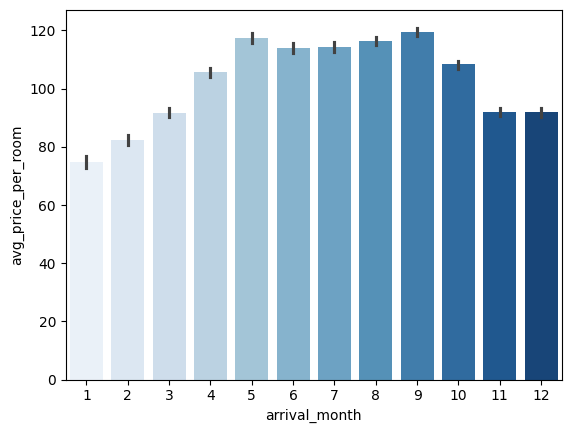

In [144]:
sns.barplot(x="arrival_month", y="avg_price_per_room", data=data, palette="Blues")

In [145]:
# For Categorical Columns
def plot_bivariate_cat(df , target , cat_features):
    num_plots = len(cat_features)
    num_rows = (len(cat_features)+1)//2

    fig , axes = plt.subplots(num_rows , 2 , figsize=(15 , num_rows*5))
    axes = axes.flatten()

    for i , column in enumerate(cat_features):
        sns.countplot(x=column, hue=target, ax=axes[i], data=data, palette="Set2")
        axes[i].set_title(f"{column} VS {target}")
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_xlabel(column)
        axes[i].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

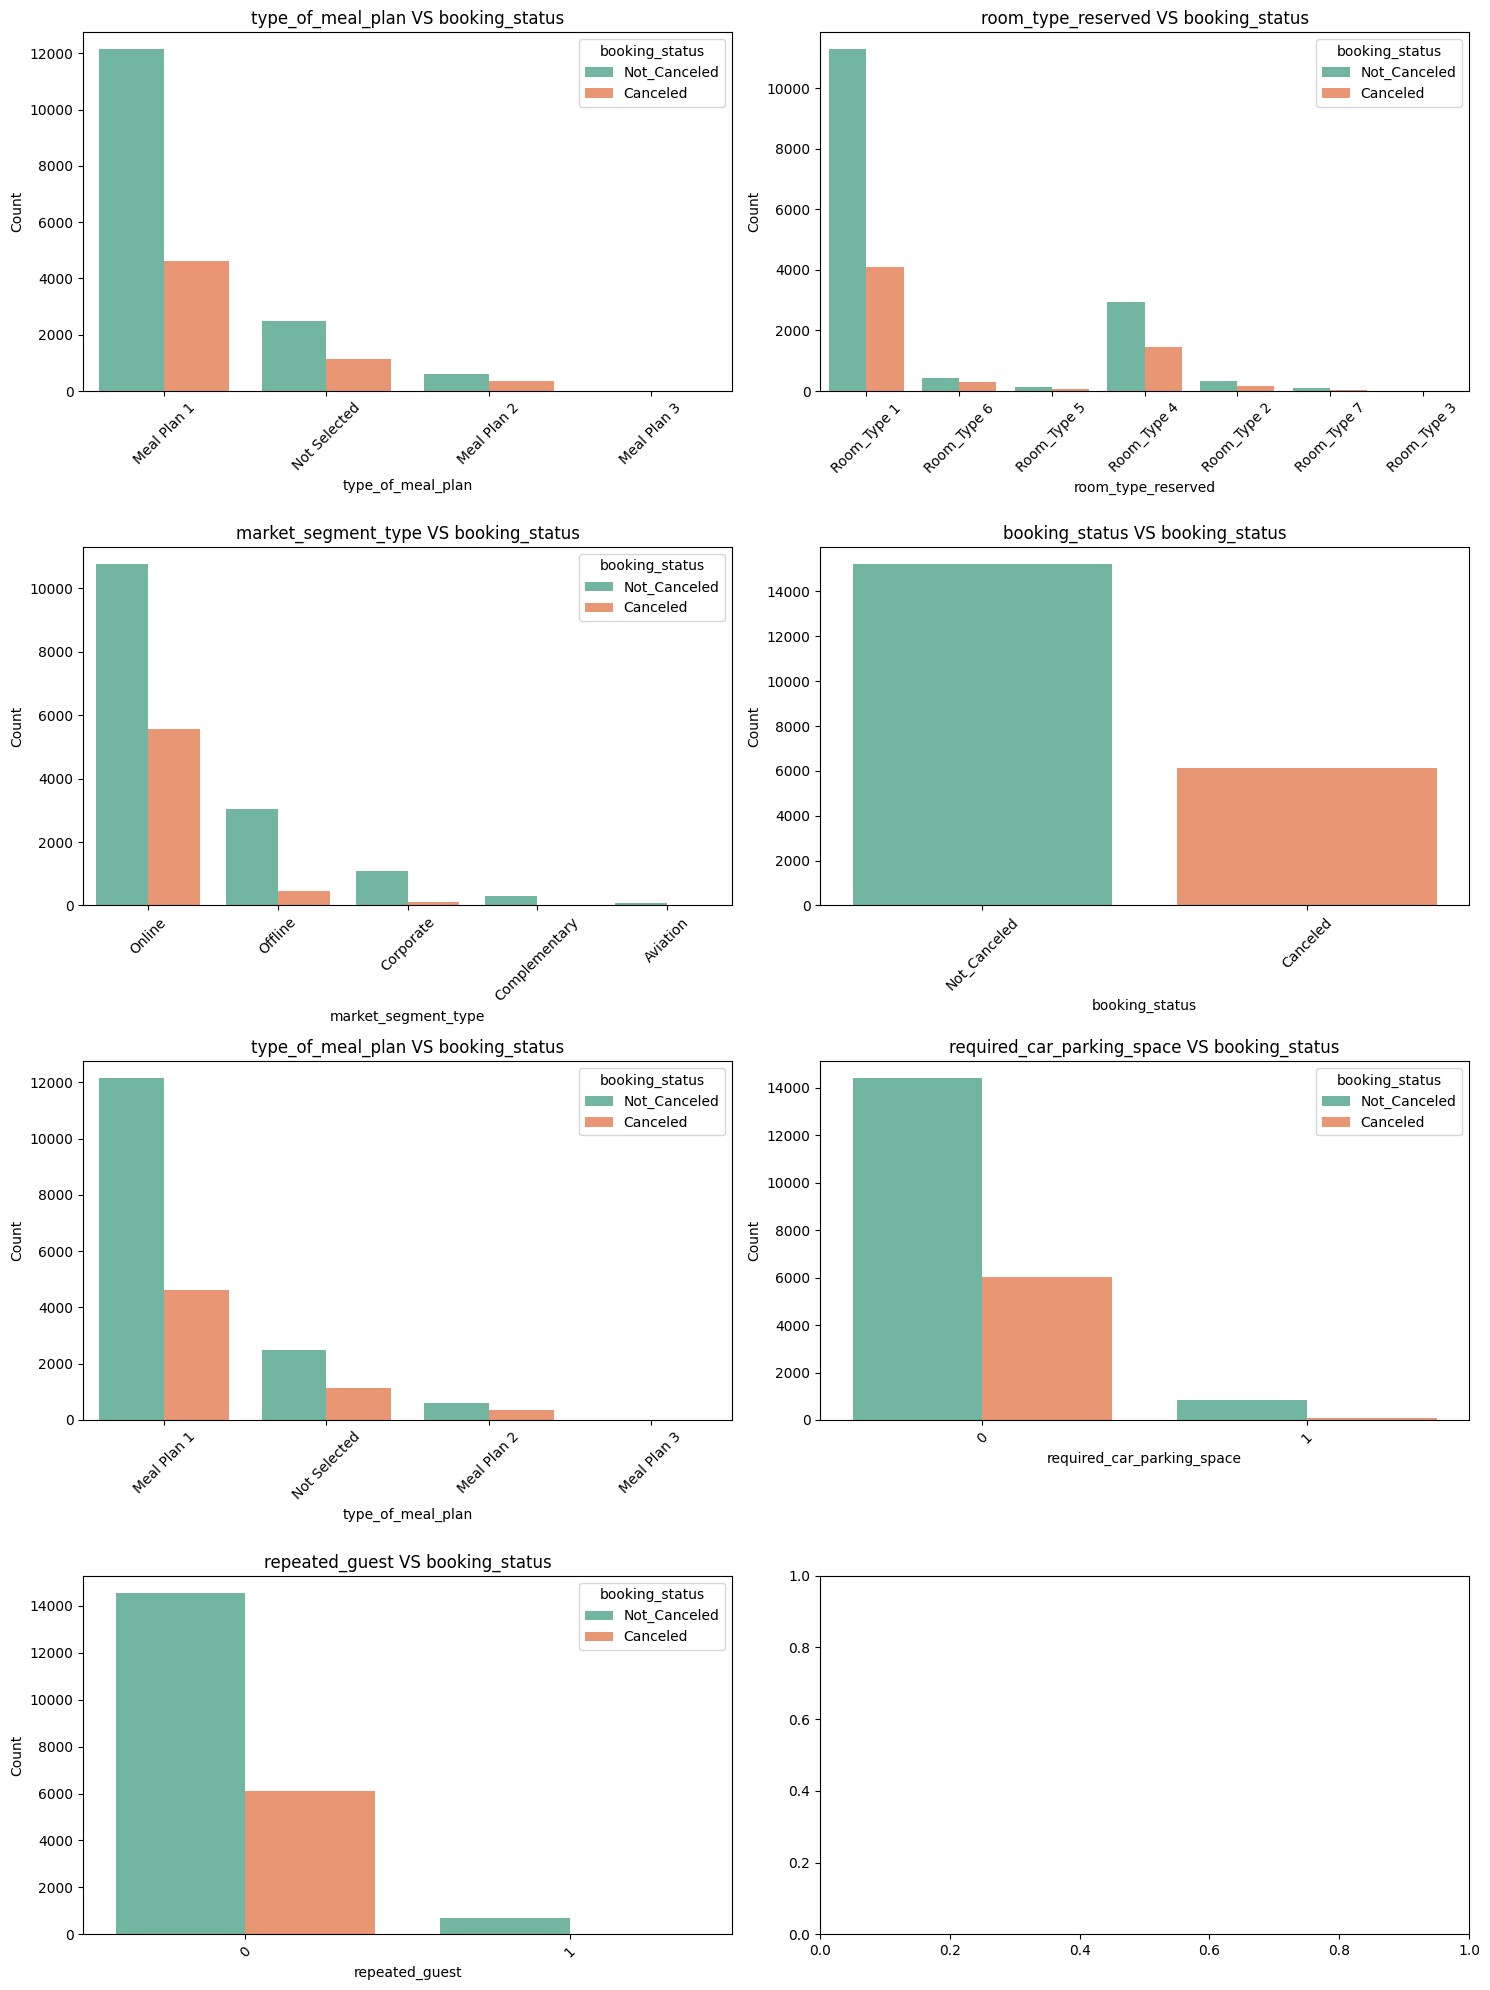

In [146]:
plot_bivariate_cat(data , "booking_status" , catogorical_columns)

##### Data Processing

In [147]:
df.info()

<class 'pandas.DataFrame'>
Index: 21359 entries, 0 to 29019
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21359 non-null  int64  
 1   no_of_children                        21359 non-null  int64  
 2   no_of_weekend_nights                  21359 non-null  int64  
 3   no_of_week_nights                     21359 non-null  int64  
 4   type_of_meal_plan                     21359 non-null  str    
 5   required_car_parking_space            21359 non-null  int64  
 6   room_type_reserved                    21359 non-null  str    
 7   lead_time                             21359 non-null  int64  
 8   arrival_year                          21359 non-null  int64  
 9   arrival_month                         21359 non-null  int64  
 10  arrival_date                          21359 non-null  int64  
 11  market_segment_type            

We have to encode the object dtype columns

In [148]:
!pip install scikit-learn

In [149]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [150]:
mappings = {}  # For storing the categorical mappings
for col in catogorical_columns:
    df[col] = le.fit_transform(df[col])
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

In [151]:
mappings

{'type_of_meal_plan': {np.int64(0): np.int64(0),
  np.int64(1): np.int64(1),
  np.int64(2): np.int64(2),
  np.int64(3): np.int64(3)},
 'room_type_reserved': {'Room_Type 1': np.int64(0),
  'Room_Type 2': np.int64(1),
  'Room_Type 3': np.int64(2),
  'Room_Type 4': np.int64(3),
  'Room_Type 5': np.int64(4),
  'Room_Type 6': np.int64(5),
  'Room_Type 7': np.int64(6)},
 'market_segment_type': {'Aviation': np.int64(0),
  'Complementary': np.int64(1),
  'Corporate': np.int64(2),
  'Offline': np.int64(3),
  'Online': np.int64(4)},
 'booking_status': {'Canceled': np.int64(0), 'Not_Canceled': np.int64(1)},
 'required_car_parking_space': {np.int64(0): np.int64(0),
  np.int64(1): np.int64(1)},
 'repeated_guest': {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}}

In [152]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,1,2,1,0,0,0,26,2017,10,17,4,0,0,0,161.00,0,1
1,2,1,1,1,0,0,0,98,2018,7,16,4,0,0,0,121.50,2,1
2,2,0,0,3,0,0,0,433,2018,9,8,3,0,0,0,70.00,0,0
3,2,0,2,5,0,0,0,195,2018,8,8,3,0,0,0,72.25,0,1
4,1,0,0,2,0,0,0,188,2018,6,15,3,0,0,0,130.00,0,0


In [153]:
df.info()

<class 'pandas.DataFrame'>
Index: 21359 entries, 0 to 29019
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          21359 non-null  int64  
 1   no_of_children                        21359 non-null  int64  
 2   no_of_weekend_nights                  21359 non-null  int64  
 3   no_of_week_nights                     21359 non-null  int64  
 4   type_of_meal_plan                     21359 non-null  int64  
 5   required_car_parking_space            21359 non-null  int64  
 6   room_type_reserved                    21359 non-null  int64  
 7   lead_time                             21359 non-null  int64  
 8   arrival_year                          21359 non-null  int64  
 9   arrival_month                         21359 non-null  int64  
 10  arrival_date                          21359 non-null  int64  
 11  market_segment_type            

#### Check for Multi-Collinearity

In [154]:
!pip install statsmodels

In [155]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


In [156]:
x = add_constant(df)
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif_data

,feature,VIF
0,const,4.100197e+07
1,no_of_adults,1.341180e+00
2,no_of_children,1.282459e+00
3,no_of_weekend_nights,1.073215e+00
4,no_of_week_nights,1.125260e+00
5,type_of_meal_plan,1.178228e+00
6,required_car_parking_space,1.036105e+00
7,room_type_reserved,1.549859e+00
8,lead_time,1.406287e+00
9,arrival_year,1.288533e+00


No multi collinearity as VIF < 5

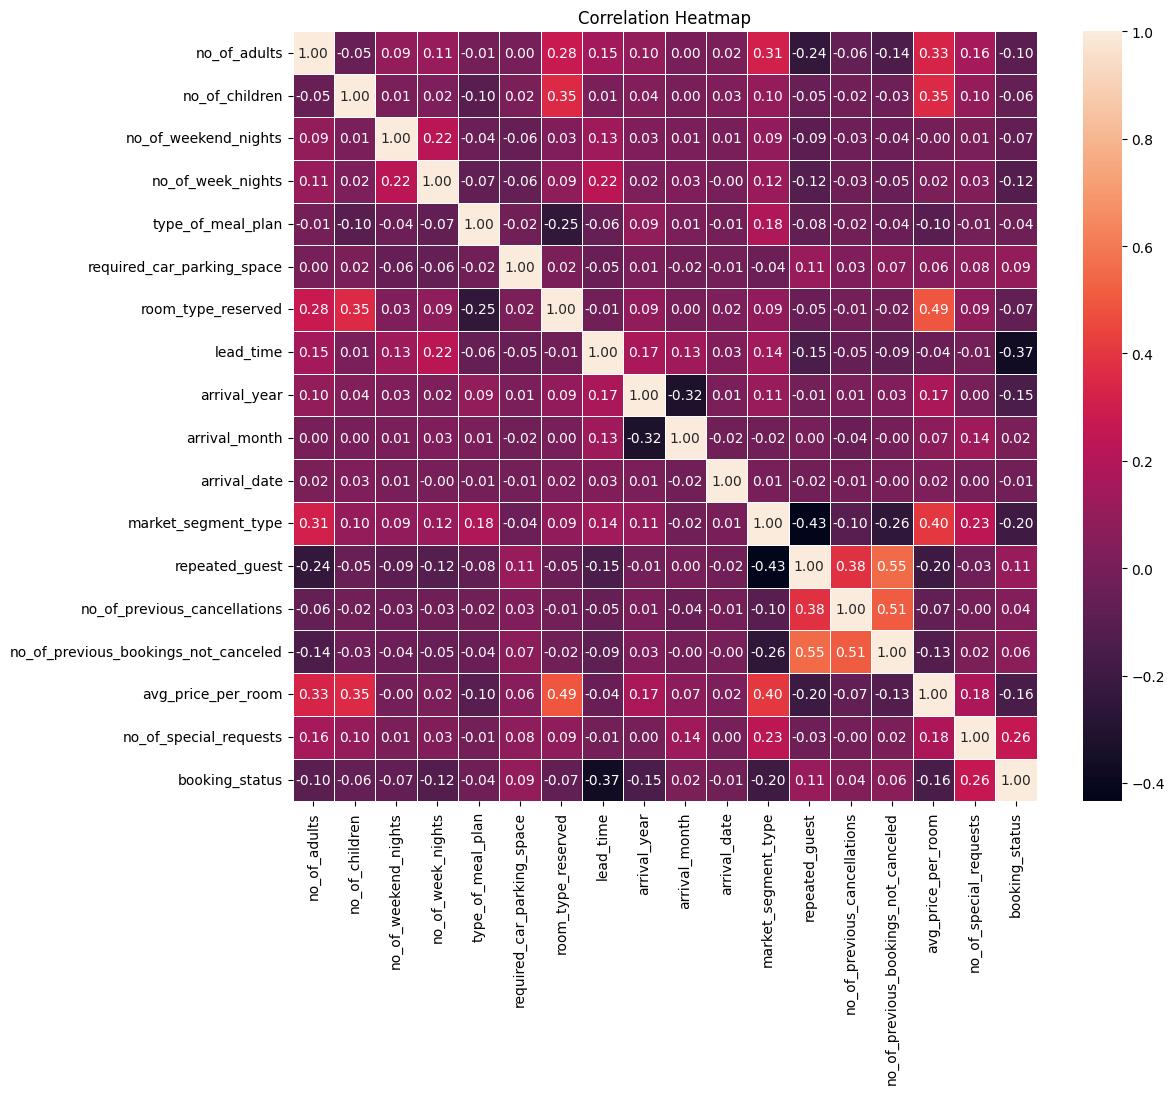

In [157]:
corr = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Check for Skewness in the feature columns

In [158]:
skewness = df.skew()
print(skewness)

no_of_adults                            -0.305652
no_of_children                           4.165696
no_of_weekend_nights                     0.636637
no_of_week_nights                        1.553657
type_of_meal_plan                        1.650716
required_car_parking_space               4.538315
room_type_reserved                       1.392145
lead_time                                1.405258
arrival_year                            -1.953273
arrival_month                           -0.293266
arrival_date                             0.010333
market_segment_type                     -2.333046
repeated_guest                           5.282330
no_of_previous_cancellations            22.001489
no_of_previous_bookings_not_canceled    16.735934
avg_price_per_room                       0.542888
no_of_special_requests                   0.922373
booking_status                          -0.942305
dtype: float64


no_of_previous_cancellations            22.001489
no_of_previous_bookings_not_canceled    16.735934

here the skewness is high and to fix this we will use log transformation

In [159]:
for cols in df.columns:
    if skewness[cols] > 5:
        df[cols] = np.log1p(df[cols])

In [160]:
skewness = df.skew()
print(skewness)

no_of_adults                            -0.305652
no_of_children                           4.165696
no_of_weekend_nights                     0.636637
no_of_week_nights                        1.553657
type_of_meal_plan                        1.650716
required_car_parking_space               4.538315
room_type_reserved                       1.392145
lead_time                                1.405258
arrival_year                            -1.953273
arrival_month                           -0.293266
arrival_date                             0.010333
market_segment_type                     -2.333046
repeated_guest                           5.282330
no_of_previous_cancellations            13.270580
no_of_previous_bookings_not_canceled     7.619850
avg_price_per_room                       0.542888
no_of_special_requests                   0.922373
booking_status                          -0.942305
dtype: float64


Skewness Fixed


Handling imbalanced data -> Use oversampling as there are less records in the dataset 


In [161]:
x = df.drop(columns=["booking_status"])
y = df["booking_status"]

In [162]:
!pip install imbalanced-learn   

In [163]:
# 1:21:46
y.value_counts()

booking_status
1    15231
0     6128
Name: count, dtype: int64

In [164]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

In [165]:
y_resampled.value_counts()

booking_status
1    15231
0    15231
Name: count, dtype: int64

In [166]:
balanced_df = pd.DataFrame(x_resampled, columns=x.columns)
balanced_df['target'] = y_resampled
balanced_df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,target
0,2,1,2,1,0,0,0,26,2017,10,17,4,0.0,0.0,0.0,161.00,0,1
1,2,1,1,1,0,0,0,98,2018,7,16,4,0.0,0.0,0.0,121.50,2,1
2,2,0,0,3,0,0,0,433,2018,9,8,3,0.0,0.0,0.0,70.00,0,0
3,2,0,2,5,0,0,0,195,2018,8,8,3,0.0,0.0,0.0,72.25,0,1
4,1,0,0,2,0,0,0,188,2018,6,15,3,0.0,0.0,0.0,130.00,0,0


In [167]:
df = balanced_df.copy()

##### Feature Selection

In [168]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
x = df.drop(columns=["target"])
y = df["target"]

In [169]:
rf.fit(x, y)
feat_imp = rf.feature_importances_

In [170]:
feat_imp_df = pd.DataFrame({
    "feature": x.columns,   
    "importance": feat_imp
})

In [171]:
feat_imp_df

,feature,importance
0,no_of_adults,0.017801
1,no_of_children,0.006765
2,no_of_weekend_nights,0.030228
3,no_of_week_nights,0.044283
4,type_of_meal_plan,0.020189
5,required_car_parking_space,0.012130
6,room_type_reserved,0.018948
7,lead_time,0.260704
8,arrival_year,0.016758
9,arrival_month,0.086583


In [172]:
top_feat_importances = feat_imp_df.sort_values(by="importance", ascending=False)
top_feat_importances

,feature,importance
7,lead_time,0.260704
16,no_of_special_requests,0.184305
15,avg_price_per_room,0.150754
9,arrival_month,0.086583
10,arrival_date,0.084006
11,market_segment_type,0.057446
3,no_of_week_nights,0.044283
2,no_of_weekend_nights,0.030228
4,type_of_meal_plan,0.020189
6,room_type_reserved,0.018948


In [173]:
top_10_features = top_feat_importances["feature"].head(10).values
top_10_df = df[top_10_features.tolist() + ["target"]]
top_10_df.head()

,lead_time,no_of_special_requests,avg_price_per_room,arrival_month,arrival_date,market_segment_type,no_of_week_nights,no_of_weekend_nights,type_of_meal_plan,room_type_reserved,target
0,26,0,161.00,10,17,4,1,2,0,0,1
1,98,2,121.50,7,16,4,1,1,0,0,1
2,433,0,70.00,9,8,3,3,0,0,0,0
3,195,0,72.25,8,8,3,5,2,0,0,1
4,188,0,130.00,6,15,3,2,0,0,0,0


In [174]:
top_10_df.shape

(30462, 11)

In [175]:
df = top_10_df.copy()

##### Model Selection

In [176]:
!pip install xgboost lightgbm 

In [177]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 

from sklearn.metrics import *

In [178]:
x = df.drop(columns=["target"])
y = df["target"]

In [179]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [180]:
classifiers = {
    "Random Forest": RandomForestClassifier(random_state=42),       
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}


In [181]:
metrics = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

In [182]:
for model_name,classifier in classifiers.items():
    classifier.fit(x_train, y_train)
    y_pred = classifier.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    metrics["Model"].append(model_name)
    metrics["Accuracy"].append(acc)
    metrics["Precision"].append(prec)
    metrics["Recall"].append(rec)
    metrics["F1 Score"].append(f1)

[LightGBM] [Info] Number of positive: 12161, number of negative: 12208
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 601
[LightGBM] [Info] Number of data points in the train set: 24369, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499036 -> initscore=-0.003857
[LightGBM] [Info] Start training from score -0.003857


In [183]:
metrics

{'Model': ['Random Forest',
  'Gradient Boosting',
  'AdaBoost',
  'Logistic Regression',
  'SVM',
  'Decision Tree',
  'Naive Bayes',
  'KNN',
  'XGBoost',
  'LightGBM'],
 'Accuracy': [0.8913507303462991,
  0.8360413589364845,
  0.8048580338092893,
  0.7749876907927129,
  0.7206630559658624,
  0.8366978499917939,
  0.7733464631544396,
  0.7797472509437059,
  0.8746102084359101,
  0.8650910881339242],
 'Precision': [0.893721386527142,
  0.8200927357032457,
  0.8015389547932029,
  0.8048080373161105,
  0.7301480484522207,
  0.8482712319570326,
  0.8032315978456014,
  0.8561417971970322,
  0.8690781049935979,
  0.8503740648379052],
 'Recall': [0.890228013029316,
  0.8641693811074919,
  0.8143322475570033,
  0.7306188925081433,
  0.7068403908794788,
  0.8231270358306189,
  0.7286644951140065,
  0.6765472312703583,
  0.8843648208469055,
  0.888599348534202],
 'F1 Score': [0.8919712793733682,
  0.8415543219666931,
  0.8078849571820973,
  0.7659211200273177,
  0.7183051969546508,
  0.8355100

In [184]:
metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.891351,0.893721,0.890228,0.891971
1,Gradient Boosting,0.836041,0.820093,0.864169,0.841554
2,AdaBoost,0.804858,0.801539,0.814332,0.807885
3,Logistic Regression,0.774988,0.804808,0.730619,0.765921
4,SVM,0.720663,0.730148,0.706840,0.718305
5,Decision Tree,0.836698,0.848271,0.823127,0.835510
6,Naive Bayes,0.773346,0.803232,0.728664,0.764133
7,KNN,0.779747,0.856142,0.676547,0.755822
8,XGBoost,0.874610,0.869078,0.884365,0.876655
9,LightGBM,0.865091,0.850374,0.888599,0.869067


In [185]:
# top 3 models based on Accuracy
metrics_df.sort_values(by="Accuracy", ascending=False).head(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.891351,0.893721,0.890228,0.891971
8,XGBoost,0.874610,0.869078,0.884365,0.876655
9,LightGBM,0.865091,0.850374,0.888599,0.869067


In [186]:
# Training Random Forest on the entire dataset
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [187]:
x = df.drop(columns=["target"])
y = df["target"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [188]:
rf = RandomForestClassifier(random_state=42)

In [189]:
params_dist = {
    'n_estimators': randint(100,500),
    'max_depth': randint(10,50),
    'min_samples_split': randint(2,12),
    'min_samples_leaf': randint(1,6),
    'bootstrap': [True, False]
}

In [190]:
random_search = RandomizedSearchCV(
    estimator=rf, param_distributions=params_dist, n_iter=30, 
    cv=5, random_state=42, n_jobs=-1,verbose=2,
    scoring='accuracy')

In [191]:
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': <scipy.stats....00211CCD31250>, 'min_samples_leaf': <scipy.stats....00211C676F460>, 'min_samples_split': <scipy.stats....00211C6A0D9D0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the vari

In [192]:
random_search.best_params_

{'bootstrap': False,
 'max_depth': 48,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 195}

In [193]:
best_rf = random_search.best_estimator_
best_rf.fit(x_train, y_train)
y_pred = best_rf.predict(x_test)

# Metrics on best rf model
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Best RF Model - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1 Score: {f1:.4f}")

Best RF Model - Accuracy: 0.8938, Precision: 0.8927, Recall: 0.8971, F1 Score: 0.8949


The metrics has increased from the previous iteration due to hyperparameter tuning

##### Saving the best model

In [194]:
import joblib
joblib.dump(best_rf, "best_rf_model.pkl")

['best_rf_model.pkl']

In [195]:
# loading the model
loaded_rf = joblib.load("best_rf_model.pkl")
loaded_rf.fit(x_train, y_train)
y_pred_loaded = loaded_rf.predict(x_test)
acc_loaded = accuracy_score(y_test, y_pred_loaded)
print(f"Loaded RF Model - Accuracy: {acc_loaded:.4f}")

Loaded RF Model - Accuracy: 0.8938


In [196]:
catogorical_columns 

['type_of_meal_plan',
 'room_type_reserved',
 'market_segment_type',
 'booking_status',
 'type_of_meal_plan',
 'required_car_parking_space',
 'repeated_guest']

In [197]:
numerical_columns

['no_of_adults',
 'no_of_children',
 'no_of_weekend_nights',
 'no_of_week_nights',
 'lead_time',
 'arrival_year',
 'arrival_month',
 'arrival_date',
 'no_of_previous_cancellations',
 'no_of_previous_bookings_not_canceled',
 'avg_price_per_room',
 'no_of_special_requests']

In [198]:
df

,lead_time,no_of_special_requests,avg_price_per_room,arrival_month,arrival_date,market_segment_type,no_of_week_nights,no_of_weekend_nights,type_of_meal_plan,room_type_reserved,target
0,26,0,161.000000,10,17,4,1,2,0,0,1
1,98,2,121.500000,7,16,4,1,1,0,0,1
2,433,0,70.000000,9,8,3,3,0,0,0,0
3,195,0,72.250000,8,8,3,5,2,0,0,1
4,188,0,130.000000,6,15,3,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
30457,265,0,111.037207,6,24,3,2,0,1,0,0
30458,103,0,72.250000,4,18,3,3,1,0,0,0
30459,27,0,104.556265,6,12,4,2,1,1,0,0
30460,46,0,107.100000,4,4,4,1,1,3,0,0


In [199]:
type(df["target"])

pandas.Series